In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Add project root to path
sys.path.append(os.path.abspath('..'))

from scipy.stats import norm, laplace
from simulator.loader import MarketDataLoader

# Parameters
ticker = "SPY"
start_date = "2014-01-01"
end_date = "2024-01-01"

# Load daily returns
loader = MarketDataLoader(tickers=[ticker], start_date=start_date, end_date=end_date)
market_data = loader.fetch_data()
returns = market_data[ticker].dropna()

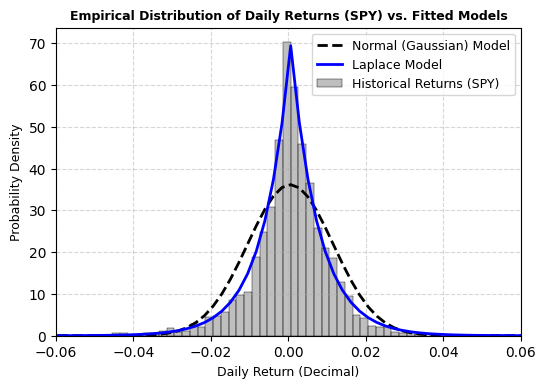

In [3]:
# Fit distributions
mu_norm, std_norm = norm.fit(returns)
loc_lap, scale_lap = laplace.fit(returns)

# Plot empirical returns and fitted models
plt.figure(figsize=(6, 4))
sns.histplot(x=returns, bins=100, stat='density', alpha=0.5, color='gray', label=f'Historical Returns ({ticker})')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

p_norm = norm.pdf(x, mu_norm, std_norm)
plt.plot(x, p_norm, 'k--', linewidth=2, label='Normal (Gaussian) Model')

p_lap = laplace.pdf(x, loc_lap, scale_lap)
plt.plot(x, p_lap, 'b-', linewidth=2, label='Laplace Model')

plt.title(f'Empirical Distribution of Daily Returns ({ticker}) vs. Fitted Models', fontsize=9, fontweight='bold')
plt.xlabel('Daily Return (Decimal)', fontsize=9)
plt.ylabel('Probability Density', fontsize=9)
plt.xlim(-0.06, 0.06)
plt.legend(fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Interpretation: Daily returns exhibit a sharp central peak and 
# heavy tails which the Laplace model fits better than the Normal.

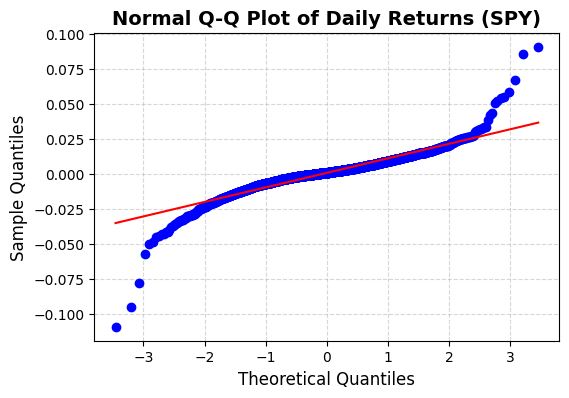

In [4]:
import scipy.stats as stats

# Generate Normal Q-Q plot
plt.figure(figsize=(6, 4))
stats.probplot(returns, dist="norm", plot=plt)

plt.title(f"Normal Q-Q Plot of Daily Returns ({ticker})", fontsize=14, fontweight="bold")
plt.xlabel("Theoretical Quantiles", fontsize=12)
plt.ylabel("Sample Quantiles", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Interpretation: Compares sorted returns (y-axis) to normal quantiles (x-axis);
# extreme deviations from the line show fat tails.

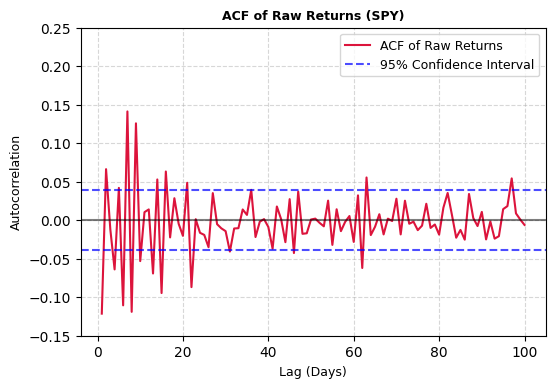

In [5]:
from statsmodels.tsa.stattools import acf

# Calculate autocorrelation for raw returns
lags = 100
acf_raw = acf(returns, nlags=lags, fft=True)[1:]

# Calculate 95% confidence interval bounds
conf_bound = 1.96 / np.sqrt(len(returns))

# Plot autocorrelation of raw returns
plt.figure(figsize=(6, 4))
plt.plot(range(1, lags + 1), acf_raw, color="crimson", label="ACF of Raw Returns")
plt.axhline(y=0, color="black", linestyle="-", alpha=0.5)
plt.axhline(y=conf_bound, color="blue", linestyle="--", alpha=0.7, label="95% Confidence Interval")
plt.axhline(y=-conf_bound, color="blue", linestyle="--", alpha=0.7)

plt.title(f"ACF of Raw Returns ({ticker})", fontsize=9, fontweight="bold")
plt.xlabel("Lag (Days)", fontsize=9)
plt.ylabel("Autocorrelation", fontsize=9)
plt.ylim(-0.15, 0.25)
plt.legend(fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Interpretation: Near-zero autocorrelation at all lags confirms daily returns are linearly unpredictable day-to-day.

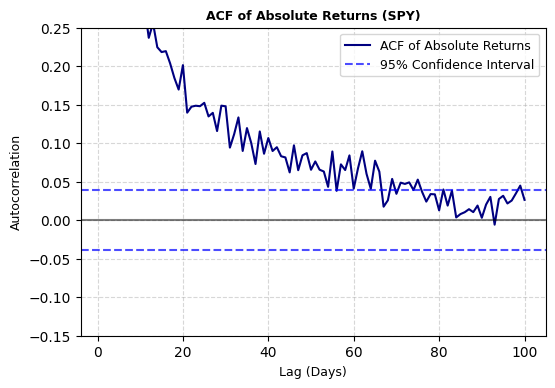

In [6]:
# Calculate autocorrelation for absolute returns
acf_abs = acf(np.abs(returns), nlags=lags, fft=True)[1:]

# Plot autocorrelation of absolute returns
plt.figure(figsize=(6, 4))
plt.plot(range(1, lags + 1), acf_abs, color="navy", label="ACF of Absolute Returns")
plt.axhline(y=0, color="black", linestyle="-", alpha=0.5)
plt.axhline(y=conf_bound, color="blue", linestyle="--", alpha=0.7, label="95% Confidence Interval")
plt.axhline(y=-conf_bound, color="blue", linestyle="--", alpha=0.7)

plt.title(f"ACF of Absolute Returns ({ticker})", fontsize=9, fontweight="bold")
plt.xlabel("Lag (Days)", fontsize=9)
plt.ylabel("Autocorrelation", fontsize=9)
plt.ylim(-0.15, 0.25)
plt.legend(fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Interpretation: High and slowly-decaying autocorrelation of absolute returns
# confirms that volatility clusters persistently over time.